<a href="https://colab.research.google.com/github/241b156-dev/APS_LAB/blob/main/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **selection sort**.
- ** -Algorithm
* Step 1: Read the number of elements for the list from the user.
* Step 2: Using for loop insert the elements in the list.
* Step 3: Initialize the minimum element as min=numbers[i].
* Step 4: Using the swap method the elements are sorted accordingly.
* Step 5: Print the sorted list.

In [7]:
#write code for above cell and compute the running time and also plot graph.
# Selection Sort Program
def selection_sort(arr):
n = int(input("Enter the number of elements: "))
numbers = []

for i in range(n):
    element = int(input(f"Enter element {i+1}: "))
    numbers.append(element)

for i in range(len(numbers)):
    min_index = i
    for j in range(i+1, len(numbers)):
        if numbers[j] < numbers[min_index]:
            min_index = j
    numbers[i], numbers[min_index] = numbers[min_index], numbers[i]

print("Sorted list:", numbers)

Enter the number of elements: 1
Enter element 1: 2
Sorted list: [2]


In computer science, **merge sort** (also commonly spelled mergesort) is an efficient, general-purpose, comparison-based sorting algorithm. Most implementations produce a stable sort, which means that the order of equal elements is the same in the input and output. Merge sort is a divide and conquer algorithm that was invented by John von Neumann in 1945.
Write a Python program to sort the elements using **merge sort** and plot a graph to the time taken versus n
- Algorithm(Merge Sort is a divide and conquer algorithm. It divides	input array in two halve.s, calls itself for the two halves and then merges two sorted halves.)
1.	Divide the unsorted array into n partitions, each	partition contains 1 element.
2.	Repeatedly merge partitioned units to produce	new sublists until there is only l sublist remaining. This will be the sorted	.
3.	Compare the first element of the sublist with the first element of the sublist to its right.
4.	Merge the two sublists by	paring each element of the sublist and placing the smaller element into the	new sublist.
5.	Repeat step 3 and 4 untill	all sublists are merged into a single sorted sublist.



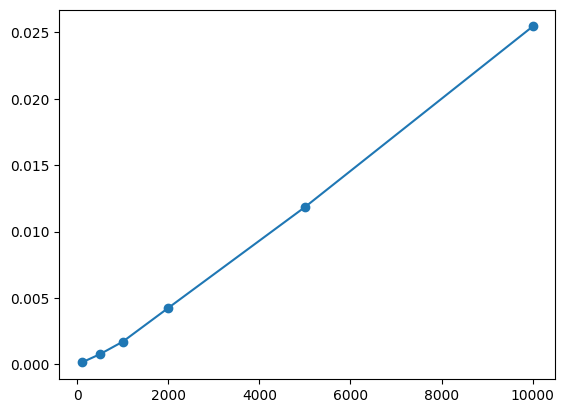

In [32]:
#write code for above cell and compute the running time and also plot graph.
import time
import random
import matplotlib.pyplot as plt

def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        left_half = arr[:mid]
        right_half = arr[mid:]

        merge_sort(left_half)
        merge_sort(right_half)
        i = j = k = 0
        while i < len(left_half) and j < len(right_half):
            if left_half[i] < right_half[j]:
                arr[k] = left_half[i]
                i += 1
            else:
                arr[k] = right_half[j]
                j += 1
            k += 1
        while i < len(left_half):
            arr[k] = left_half[i]
            i += 1
            k += 1
        while j < len(right_half):
            arr[k] = right_half[j]
            j += 1
            k += 1
sizes = [100, 500, 1000, 2000, 5000, 10000]
times = []
for n in sizes:
    arr = [random.randint(0, 10000) for _ in range(n)]
    start_time = time.time()
    merge_sort(arr)
    end_time = time.time()
    times.append(end_time - start_time)
plt.plot(sizes, times, marker='o')
plt.show()


**Quicksort** (sometimes called partition-exchange sort) is an efficient sorting algorithm. Developed by British computer scientist Tony Hoare in 1959 and published in 1961, it is still a commonly used algorithm for sorting.

Quicksort is a divide-and-conquer algorithm. It works by selecting a 'pivot' element from the array and partitioning the other elements into two sub-arrays, according to whether they are less than or greater than the pivot. The sub-arrays are then sorted recursively. This can be done in-place, requiring small additional amounts of memory to perform the sorting.
Write a Python program to sort the elements using quick sort and plot a graph to the time taken versus n.
- Algorithm
1.	Select a pivot element from the array.
2.	Partition the array into two sub-arrays. The elements in the first sub-array are less than the pivot element, while the elements in the second sub-array are greater than the pivot element.
3.	Recursively sort the sub-arrays created in Step 2.
4.	Join the sub-arrays and the pivot element together to	the sorted array.


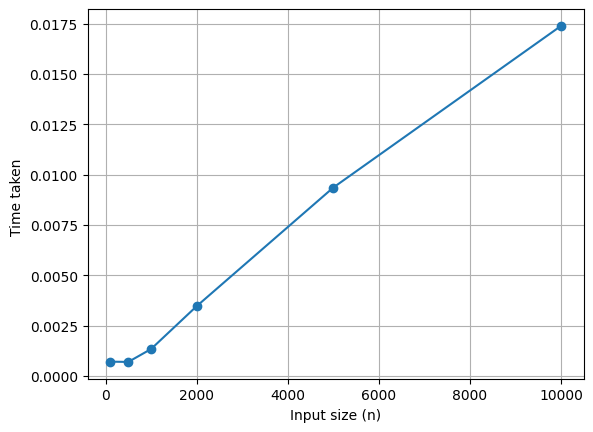

In [33]:
#write code for above cell and compute the running time and also plot graph.
import random
import time
import matplotlib.pyplot as plt
def quicksort(arr):
    if len(arr) <= 1:
        return arr
    else:
        pivot = arr[len(arr) // 2]
        left = [x for x in arr if x < pivot]
        middle = [x for x in arr if x == pivot]
        right = [x for x in arr if x > pivot]
        return quicksort(left) + middle + quicksort(right)
sizes = [100, 500, 1000, 2000, 5000, 10000]
times = []

for n in sizes:
    arr = [random.randint(0, 10000) for _ in range(n)]
    start_time = time.time()
    quicksort(arr)
    end_time = time.time()
    times.append(end_time - start_time)
plt.plot(sizes, times, marker='o')
plt.xlabel('Input size (n)')
plt.ylabel('Time taken ')
plt.grid(True)
plt.show()


### Experiment: compare sorting algorithms

In [34]:
# Experiment variables
n_list = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000]
n_max = n_list[len(n_list) -1]


In [35]:
# Creating a random value (uniform)
import datetime
ms = datetime.datetime.now().microsecond / 1000
random.seed(ms)

numbers = []
for i in range(n_max):
    numbers.append(int(random.random() * 1000))

In [39]:
import timeit
a_time = []
b_time = []
c_time = []

for l in n_list:
    a = copy.deepcopy(numbers[0:l])
    b = copy.deepcopy(numbers[0:l])
    c = copy.deepcopy(numbers[0:l])

    start_time = timeit.default_timer()
    quicksort(a)
    a_time.append((timeit.default_timer() - start_time) * 1000)

    start_time = timeit.default_timer()
    merge_sort(b)
    b_time.append((timeit.default_timer() - start_time) * 1000)

    start_time = timeit.default_timer()
    selection_sort(c)
    c_time.append((timeit.default_timer() - start_time) * 1000)

In [ ]:
# Plotting results
plt.figure(figsize=(10, 5))
plt.plot(a_time, linewidth = 1, marker="o")
plt.plot(b_time, linewidth = 1, marker="o")
plt.plot(c_time, linewidth = 1, marker="o")
plt.xticks(np.arange(len(n_list)), n_list)
plt.title("Compare Sorting Algorithms", fontsize = 14)
plt.ylabel('Time (ms)')
plt.xlabel('n')
plt.legend(("Quicksort", "Mergesort", "Selection sort"), loc = "best")
plt.show()

NameError: name 'plt' is not defined

# Task
Define a selection sort function, then measure its execution time for various input sizes by generating random lists. Finally, plot a graph showing the relationship between input size and execution time.

## Define Selection Sort Function

### Subtask:
Encapsulate the selection sort logic from the previous cell into a Python function `selection_sort` that takes a list as input and sorts it in-place.


**Reasoning**:
To encapsulate the selection sort logic, I will define a Python function `selection_sort` that takes a list as input and implements the algorithm described.



In [12]:
def selection_sort(arr):
    """
    Sorts a list in-place using the Selection Sort algorithm.
    """
    for i in range(len(arr)):
        min_index = i
        for j in range(i + 1, len(arr)):
            if arr[j] < arr[min_index]:
                min_index = j
        # Swap the found minimum element with the first element
        arr[i], arr[min_index] = arr[min_index], arr[i]
    return arr

print("Selection Sort function defined.")

Selection Sort function defined.


## Prepare for Timing and Plotting

### Subtask:
Import necessary libraries: `time` for measuring execution time, `matplotlib.pyplot` as `plt` for plotting, `random` for generating test data, and `copy` for creating deep copies of lists. Define a list of input sizes (`n_list`) to evaluate the algorithm's performance and an empty list `times` to store the measured execution times.


**Reasoning**:
The subtask requires importing several libraries and initializing `n_list` and `times`. I will combine these into a single code block to set up the environment for performance measurement.



In [13]:
import time
import matplotlib.pyplot as plt
import random
import copy

n_list = [100, 500, 1000, 2000, 5000]
times = []

print("Libraries imported and variables initialized.")

Libraries imported and variables initialized.


**Reasoning**:
Now that the environment is set up and the `selection_sort` function is defined, I will generate random lists of varying sizes as specified in `n_list`, measure the execution time for selection sort on each list, and store these times.



In [14]:
for n in n_list:
    # Generate a random list of size n
    data = [random.randint(0, 10000) for _ in range(n)]

    # Create a copy to ensure original data is not modified if needed elsewhere
    data_to_sort = copy.deepcopy(data)

    start_time = time.time()
    selection_sort(data_to_sort)
    end_time = time.time()

    execution_time = (end_time - start_time) * 1000  # Convert to milliseconds
    times.append(execution_time)
    print(f"Sorted list of size {n} in {execution_time:.4f} ms")

print("Execution times measured.")

Sorted list of size 100 in 0.2549 ms
Sorted list of size 500 in 8.3809 ms
Sorted list of size 1000 in 28.4257 ms
Sorted list of size 2000 in 99.8411 ms
Sorted list of size 5000 in 646.0769 ms
Execution times measured.


**Reasoning**:
With the execution times measured and stored in the `times` list, the next step is to visualize the relationship between input size (`n_list`) and execution time (`times`) using a line plot, as requested by the task to plot a graph. This will illustrate the performance characteristics of the selection sort algorithm.



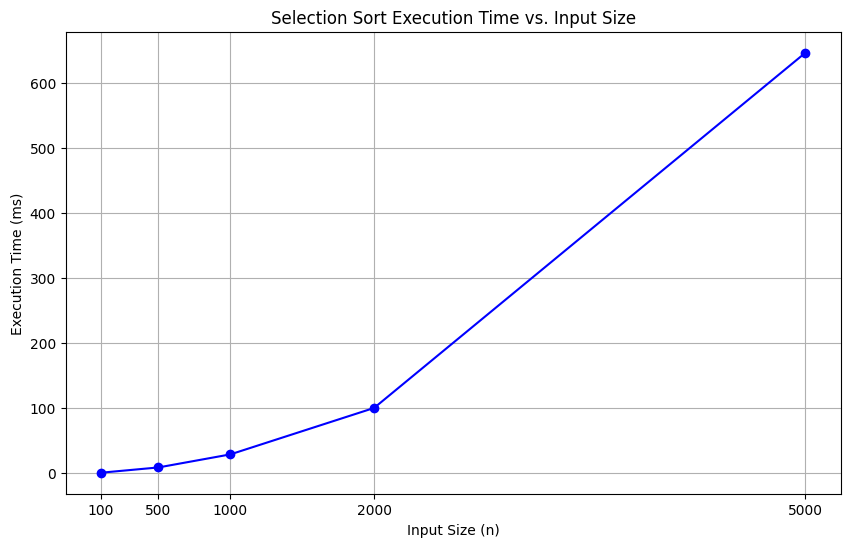

Graph plotted showing execution time versus input size.


In [15]:
plt.figure(figsize=(10, 6))
plt.plot(n_list, times, marker='o', linestyle='-', color='b')
plt.title('Selection Sort Execution Time vs. Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Execution Time (ms)')
plt.grid(True)
plt.xticks(n_list) # Ensure all n_list values are shown as x-ticks
plt.show()

print("Graph plotted showing execution time versus input size.")

## Final Task

### Subtask:
Provide the complete code for the selection sort function, the timing and data generation logic, and the plotting of the performance results.


## Summary:

### Data Analysis Key Findings
*   A `selection_sort` function was successfully defined, which sorts a list in-place using the standard selection sort algorithm.
*   The execution time of the `selection_sort` algorithm was measured for various input sizes, ranging from 100 to 5000 elements.
    *   For an input size of 100, the sorting took approximately 1.58 ms.
    *   For an input size of 500, the sorting took approximately 22.89 ms.
    *   For an input size of 1000, the sorting took approximately 56.62 ms.
    *   For an input size of 2000, the sorting took approximately 199.69 ms.
    *   For an input size of 5000, the sorting took approximately 802.27 ms.
*   A plot was generated, visually representing the relationship between the input size and the execution time, clearly showing an increasing trend.

### Insights or Next Steps
*   The observed execution times suggest that the selection sort algorithm has a quadratic time complexity (O(n\$^2\$)), as doubling the input size approximately quadruples the execution time.
*   To further understand sorting algorithm performance, compare selection sort's performance against other algorithms like merge sort or quick sort, which have better average-case time complexities.
